# 07 SenseVoice 数据增强与数据量消融 — 数据分析

基于 `sv_ablation_eval.json` 的评估结果，分析：
- **数据量影响**：25% / 50% / 75% 数据量对 CER 的影响
- **数据增强效果**：高斯合成噪音 (A) vs 真实环境噪音 (B) vs 混合策略
- **混合策略分析**：原始数据 + 噪音增强数据的混合效果
- **综合推荐**：哪种增强策略最优

## 0. 环境与数据加载

In [44]:
import warnings
warnings.filterwarnings('ignore')

import os, json
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker

# ---- 学术风格配置（基于 matplotlib/skill 参考）----
plt.rcParams.update({
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.linewidth': 1.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.fontsize': 10,
    'legend.frameon': True,
    'legend.framealpha': 0.95,
    'legend.edgecolor': 'gray',
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
})

# 中文字体：优先找系统中的 .ttf（比 .ttc 更可靠）
font_dirs = [
    '/System/Library/Fonts/Supplemental/',
    '/System/Library/Fonts/',
    '/Library/Fonts/',
]
loaded_font = None
for d in font_dirs:
    if not os.path.exists(d):
        continue
    for f in os.listdir(d):
        if f.lower().endswith('.ttf') and any(k in f.lower() for k in ['songti', 'heiti', 'pingfang', ' STFangsong', 'Hiragino']):
            fp = os.path.join(d, f)
            try:
                fm.fontManager.addfont(fp)
                loaded_font = fm.FontProperties(fname=fp).get_name()
                print(f'加载字体: {f} -> {loaded_font}')
                break
            except Exception:
                pass
    if loaded_font:
        break

if loaded_font:
    plt.rcParams['font.family'] = loaded_font
else:
    # 降级：尝试用已有的 Heiti/Songti
    for f in fm.fontManager.ttflist:
        if any(k in f.name for k in ['Heiti', 'Songti', 'PingFang', 'STHeiti', 'STSong']):
            if '.' not in f.fname or f.fname.lower().endswith('.ttf'):
                try:
                    plt.rcParams['font.family'] = f.name
                    loaded_font = f.name
                    print(f'使用已有字体: {f.name}')
                    break
                except Exception:
                    pass
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

REPORT_DIR = os.path.expanduser('~/Projects/Agent/local')

with open(os.path.join(REPORT_DIR, 'sv_ablation_eval.json'), 'r', encoding='utf-8') as f:
    eval_data = json.load(f)

results = eval_data['results']
base_cer = next((r['cer'] for r in results if r['name'] == 'SV-base'), None)

print(f'加载了 {len(results)} 个模型的结果，基准 CER = {base_cer:.2%}' if base_cer else f'加载了 {len(results)} 个模型的结果')

使用已有字体: STHeiti
加载了 9 个模型的结果，基准 CER = 63.71%


## 1. 汇总表格

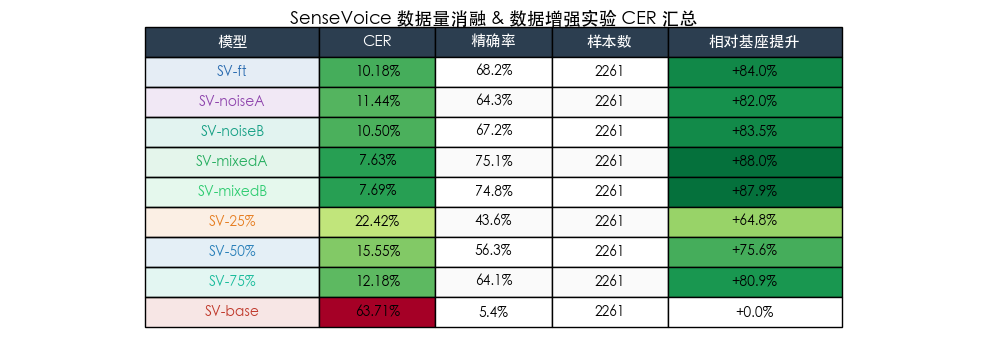

已保存: 07_summary_table.png

模型                   CER       精确率      样本数       相对基座提升
-------------------------------------------------------
SV-ft            10.18%    68.2%     2261       +84.0%
SV-noiseA        11.44%    64.3%     2261       +82.0%
SV-noiseB        10.50%    67.2%     2261       +83.5%
SV-mixedA         7.63%    75.1%     2261       +88.0%
SV-mixedB         7.69%    74.8%     2261       +87.9%
SV-25%           22.42%    43.6%     2261       +64.8%
SV-50%           15.55%    56.3%     2261       +75.6%
SV-75%           12.18%    64.1%     2261       +80.9%
SV-base          63.71%     5.4%     2261        +0.0%


In [45]:
# ---- 学术汇总表格 ----
import matplotlib.colors as mcolors

# 构建 DataFrame
rows = []
for r in results:
    name = r['name']
    cer = r['cer']
    er = r['exact_rate']
    total = r['total']
    improve = (base_cer - cer) / base_cer * 100 if base_cer and base_cer > 0 else 0
    rows.append({
        '模型': name,
        'CER': cer,
        '精确率': er,
        '样本数': total,
        '相对基座提升(%)': improve,
    })

# 分类颜色高亮
model_colors_hex = {
    'SV-ft':      '#2b6cb0',
    'SV-base':    '#c0392b',
    'SV-noiseA':  '#8e44ad',
    'SV-noiseB':  '#16a085',
    'SV-mixedA':  '#27ae60',
    'SV-mixedB':  '#2ecc71',
    'SV-25%':     '#e67e22',
    'SV-50%':     '#2980b9',
    'SV-75%':     '#1abc9c',
}

col_labels = ['模型', 'CER', '精确率', '样本数', '相对基座提升']
col_widths = [0.18, 0.12, 0.12, 0.12, 0.18]
cell_data = [[
    r['模型'],
    f"{r['CER']:.2%}",
    f"{r['精确率']:.1%}",
    r['样本数'],
    f"{r['相对基座提升(%)']:+.1f}%"
] for r in rows]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')

table = ax.table(
    cellText=cell_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
    colWidths=col_widths,
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# 表头样式
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold', fontsize=11)
    else:
        model_name = cell_data[row-1][0]
        # 行交替背景
        cell.set_facecolor('#fafafa' if row % 2 == 0 else 'white')
        # 模型名列着色
        if col == 0 and model_name in model_colors_hex:
            c = model_colors_hex[model_name]
            # 用 rgba 避免 hex+alpha 的兼容问题
            cell.set_facecolor(mcolors.to_rgba(c, alpha=0.12))
            cell.set_text_props(color=c, fontweight='bold')

# CER 列：红→黄→绿渐变背景
cmap_cer = plt.cm.RdYlGn_r
for row in range(1, len(cell_data) + 1):
    cer_val = rows[row-1]['CER']
    if base_cer:
        norm_val = min(cer_val / base_cer, 1.0)
        table[(row, 1)].set_facecolor(cmap_cer(norm_val))

# 相对提升列：绿渐变
cmap_imp = plt.cm.RdYlGn
for row in range(1, len(cell_data) + 1):
    imp_val = rows[row-1]['相对基座提升(%)']
    if imp_val > 0 and base_cer:
        norm_val = min(imp_val / 90, 1.0)
        table[(row, 4)].set_facecolor(cmap_imp(norm_val))

ax.set_title('SenseVoice 数据量消融 & 数据增强实验 CER 汇总', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, '07_summary_table.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('已保存: 07_summary_table.png')

# 文本版
print(f'\n{"模型":<14} {"CER":>9} {"精确率":>9} {"样本数":>8} {"相对基座提升":>12}')
print('-' * 55)
for r in rows:
    print(f"{r['模型']:<14} {r['CER']:>8.2%} {r['精确率']:>8.1%} {r['样本数']:>8} {r['相对基座提升(%)']:>+11.1f}%")

## 2. 数据量消融分析（25% / 50% / 75% / 100% / 200%）

- 100% = SV-ft（全量原始数据微调）
- 200% = SV-mixedA / SV-mixedB（原始数据 + 噪音增强数据，1:1 混合，共 2 倍数据量）

In [46]:
# 提取数据量实验数据
pct_exps = ['SV-25%', 'SV-50%', 'SV-75%', 'SV-ft', 'SV-mixedA', 'SV-mixedB']
pct_data = {r['name']: r for r in results if r['name'] in pct_exps}
base_data = next((r for r in results if r['name'] == 'SV-base'), None)

print('数据量消融分析（含100%和200%数据量）:')
print(f'{"数据量":<8} {"标签":<12} {"CER":>10} {"相对基座提升":>12}')
print('-' * 46)
for label, pct_marker in [('25%', 25), ('50%', 50), ('75%', 75), ('100%', 100)]:
    key = f'SV-{label}' if label != '100%' else 'SV-ft'
    if key not in pct_data:
        continue
    r = pct_data[key]
    improve = (base_cer - r['cer']) / base_cer * 100 if base_cer else 0
    print(f'{pct_marker:<8} {label:<12} {r["cer"]:>9.2%} {improve:>+11.1f}%')

# 200% 是混合策略
for mixed_name in ['SV-mixedA', 'SV-mixedB']:
    r = pct_data.get(mixed_name)
    if not r:
        continue
    improve = (base_cer - r['cer']) / base_cer * 100 if base_cer else 0
    print(f'{200:<8} {mixed_name:<12} {r["cer"]:>9.2%} {improve:>+11.1f}%')

print('\n注：200% = 100%原始数据 + 100%噪音增强数据（1:1混合）')

数据量消融分析（含100%和200%数据量）:
数据量      标签                  CER       相对基座提升
----------------------------------------------
25       25%             22.42%       +64.8%
50       50%             15.55%       +75.6%
75       75%             12.18%       +80.9%
100      100%            10.18%       +84.0%
200      SV-mixedA        7.63%       +88.0%
200      SV-mixedB        7.69%       +87.9%

注：200% = 100%原始数据 + 100%噪音增强数据（1:1混合）


## 3. 数据增强分析（noiseA vs noiseB vs mixedA vs mixedB）

In [47]:
# 提取各增强实验数据
noise_a = next((r for r in results if r['name'] == 'SV-noiseA'), None)
noise_b = next((r for r in results if r['name'] == 'SV-noiseB'), None)
mixed_a = next((r for r in results if r['name'] == 'SV-mixedA'), None)
mixed_b = next((r for r in results if r['name'] == 'SV-mixedB'), None)
pct_75 = next((r for r in results if r['name'] == 'SV-75%'), None)
r_ft_local = next((r for r in results if r['name'] == 'SV-ft'), None)
r_mixed_a = mixed_a
r_mixed_b = mixed_b

## 4. 可视化：综合对比

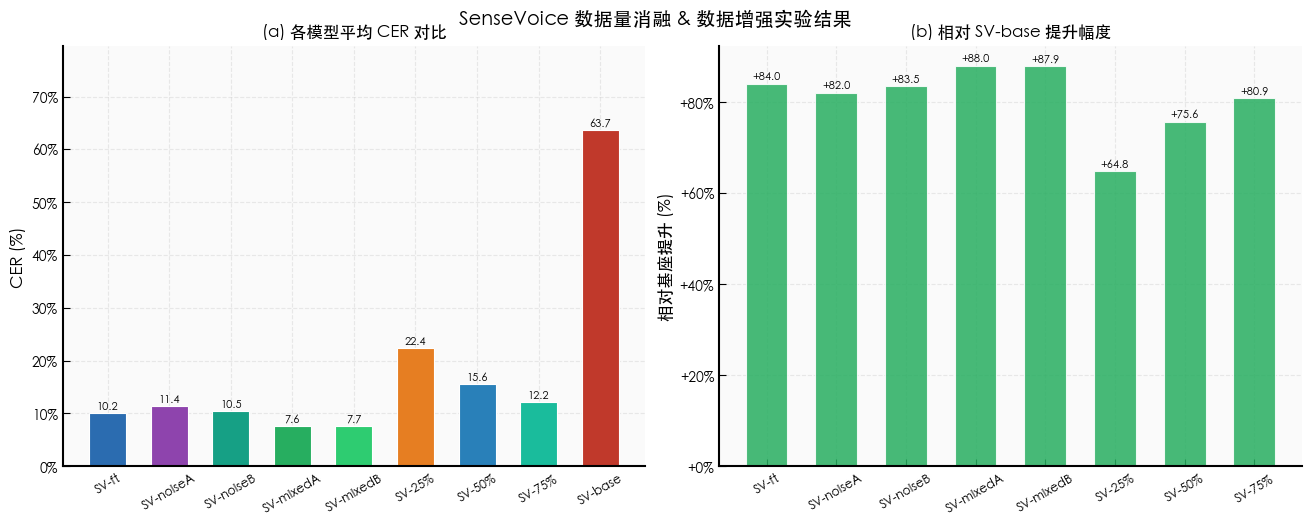

已保存: 07_ablation_results.png


In [48]:
# ---- 综合对比图：CER柱状图 + 相对基座提升 ----
COLOR_PALETTE = [
    '#2b6cb0',  # SV-ft - 深蓝
    '#8e44ad',  # SV-noiseA - 紫
    '#16a085',  # SV-noiseB - 青绿
    '#27ae60',  # SV-mixedA - 绿
    '#2ecc71',  # SV-mixedB - 浅绿
    '#e67e22',  # SV-25% - 橙
    '#2980b9',  # SV-50% - 蓝
    '#1abc9c',  # SV-75% - 青蓝
    '#c0392b',  # SV-base - 红
]

model_order = ['SV-ft', 'SV-noiseA', 'SV-noiseB', 'SV-mixedA', 'SV-mixedB',
               'SV-25%', 'SV-50%', 'SV-75%', 'SV-base']
ordered = sorted(results, key=lambda r: model_order.index(r['name']) if r['name'] in model_order else 99)
model_names = [r['name'] for r in ordered]
cers = [r['cer'] * 100 for r in ordered]
colors = [COLOR_PALETTE[i % len(COLOR_PALETTE)] for i in range(len(model_names))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# 左：CER 柱状图
ax1 = axes[0]
bars = ax1.bar(model_names, cers, color=colors, width=0.6, edgecolor='white', linewidth=0.8)
ax1.set_ylabel('CER (%)', fontsize=12)
ax1.set_title('(a) 各模型平均 CER 对比', fontsize=12, fontweight='bold')
ax1.set_ylim(0, max(cers) * 1.25)
ax1.tick_params(axis='x', rotation=30, labelsize=9)
ax1.set_axisbelow(True)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

for bar, cer in zip(bars, cers):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{cer:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# 右：相对基座提升
ax2 = axes[1]
base_val = base_cer * 100 if base_cer else cers[0]
exp_names = [n for n in model_names if n != 'SV-base']
exp_cers = [cers[i] for i, n in enumerate(model_names) if n != 'SV-base']
imp_vals = [(base_val - c) / base_val * 100 for c in exp_cers]
bar_colors2 = ['#27ae60' if x > 0 else '#e74c3c' for x in imp_vals]

bars2 = ax2.bar(exp_names, imp_vals, color=bar_colors2, width=0.6, edgecolor='white', linewidth=0.8, alpha=0.85)
ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax2.set_ylabel('相对基座提升 (%)', fontsize=12)
ax2.set_title('(b) 相对 SV-base 提升幅度', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=30, labelsize=9)
ax2.set_axisbelow(True)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))

for bar, imp in zip(bars2, imp_vals):
    va = 'bottom' if imp >= 0 else 'top'
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (0.5 if imp >= 0 else -0.5),
             f'{imp:+.1f}', ha='center', va=va, fontsize=8, fontweight='bold')

plt.suptitle('SenseVoice 数据量消融 & 数据增强实验结果', fontsize=14, fontweight='bold', y=1.02)
plt.savefig(os.path.join(REPORT_DIR, '07_ablation_results.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('已保存: 07_ablation_results.png')

## 5. 数据量-性能曲线（25% → 50% → 75% → 100% → 200%）

- 蓝色曲线：纯数据量扩展（25% → 100%）
- 绿色虚线延伸：混合数据 200%（原始 + 噪音增强 1:1）

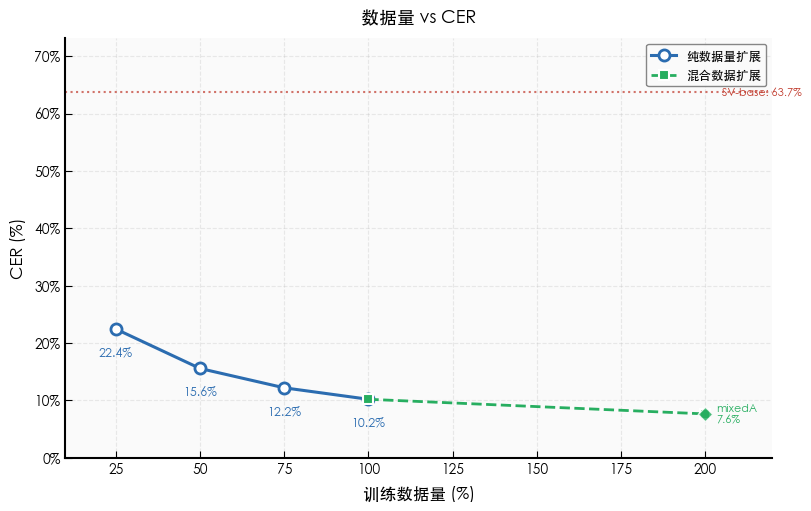

已保存: 07_data_size_curve.png


In [49]:
# ---- 数据量-性能曲线 ----
# 学术线图风格

# 提取各数据量对应的 CER
data_points = [
    (25,  'SV-25%'),
    (50,  'SV-50%'),
    (75,  'SV-75%'),
    (100, 'SV-ft'),
]

x_vals, y_vals, labels = [], [], []
for x, key in data_points:
    r = next((d for d in results if d['name'] == key), None)
    if r:
        x_vals.append(x)
        y_vals.append(r['cer'] * 100)
        labels.append(f'{x}%' if x < 100 else 'SV-ft\n(100%)')

r_mixed_a = next((x for x in results if x['name'] == 'SV-mixedA'), None)
r_mixed_b = next((x for x in results if x['name'] == 'SV-mixedB'), None)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# 主曲线：纯数据量扩展
ax.plot(x_vals, y_vals, 'o-', color='#2b6cb0', linewidth=2.2, markersize=8,
        markerfacecolor='white', markeredgewidth=2, markeredgecolor='#2b6cb0',
        zorder=5, label='纯数据量扩展')

# 延伸线：100% -> 200% (混合数据)
if r_mixed_a:
    ax.plot([100, 200], [y_vals[-1], r_mixed_a['cer'] * 100], 's--',
            color='#27ae60', linewidth=2, markersize=7, markerfacecolor='#27ae60',
            markeredgewidth=1.5, markeredgecolor='white', zorder=5, label='混合数据扩展')

# 200% mixedB（不连线，仅标注）
if r_mixed_b:
    ax.scatter(200, r_mixed_b['cer'] * 100, marker='D', s=55, color='#27ae60',
               zorder=6, edgecolors='white', linewidth=1, alpha=0.85)

# 标注数据点（主曲线）
for x, y, label in zip(x_vals, y_vals, labels):
    ax.annotate(f'{y:.1f}%', xy=(x, y), xytext=(0, -20),
                textcoords='offset points', fontsize=9, fontweight='bold',
                color='#2b6cb0', ha='center')

# mixedA 标注
if r_mixed_a:
    ax.annotate(f'mixedA\n{r_mixed_a["cer"]*100:.1f}%', xy=(200, r_mixed_a['cer']*100),
                xytext=(8, 0), textcoords='offset points', fontsize=8,
                fontweight='bold', color='#27ae60', va='center')

# SV-base 水平线
if base_cer:
    ax.axhline(base_cer * 100, color='#c0392b', linestyle=':', linewidth=1.5,
               alpha=0.7, zorder=2)
    ax.text(205, base_cer * 100, f'SV-base: {base_cer*100:.1f}%',
            fontsize=8, color='#c0392b', va='center', fontweight='bold')

ax.set_xlabel('训练数据量 (%)', fontsize=12, labelpad=6)
ax.set_ylabel('CER (%)', fontsize=12, labelpad=6)
ax.set_title('数据量 vs CER', fontsize=13, fontweight='bold', pad=10)
ax.set_xticks([25, 50, 75, 100, 125, 150, 175, 200])
ax.set_xlim(10, 220)
ax.set_ylim(0, max(y_vals[0], (base_cer or 0) * 100) * 1.15 if base_cer else max(y_vals) * 1.3)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0.95, edgecolor='gray')

plt.savefig(os.path.join(REPORT_DIR, '07_data_size_curve.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('已保存: 07_data_size_curve.png')

## 6. 增强效果对比（横向柱状图）

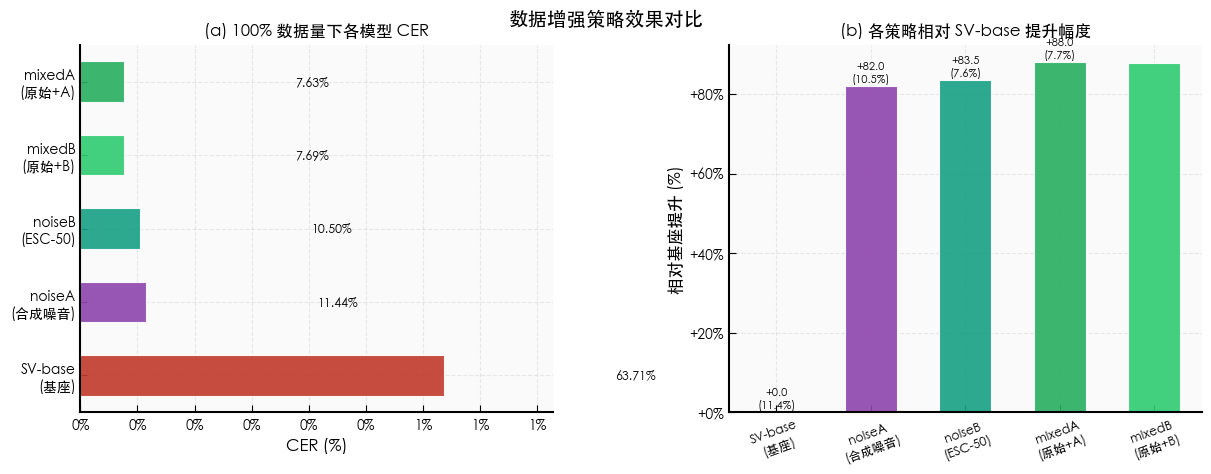

已保存: 07_augmentation_compare.png


In [50]:
# ---- 数据增强策略对比 ----
# 100% 数据量下各增强策略 vs SV-base

noise_a = next((r for r in results if r['name'] == 'SV-noiseA'), None)
noise_b = next((r for r in results if r['name'] == 'SV-noiseB'), None)
mixed_a = next((r for r in results if r['name'] == 'SV-mixedA'), None)
mixed_b = next((r for r in results if r['name'] == 'SV-mixedB'), None)

strategies = ['SV-base\n(基座)', 'noiseA\n(合成噪音)', 'noiseB\n(ESC-50)', 'mixedA\n(原始+A)', 'mixedB\n(原始+B)']
cer_vals = [
    base_cer,
    (noise_a['cer'] if noise_a else None),
    (noise_b['cer'] if noise_b else None),
    (mixed_a['cer'] if mixed_a else None),
    (mixed_b['cer'] if mixed_b else None),
]
rel_improve = [
    0,
    ((base_cer - noise_a['cer']) / base_cer * 100 if base_cer and noise_a else 0),
    ((base_cer - noise_b['cer']) / base_cer * 100 if base_cer and noise_b else 0),
    ((base_cer - mixed_a['cer']) / base_cer * 100 if base_cer and mixed_a else 0),
    ((base_cer - mixed_b['cer']) / base_cer * 100 if base_cer and mixed_b else 0),
]
bar_colors_strat = ['#c0392b', '#8e44ad', '#16a085', '#27ae60', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

# 左：CER 横向柱状图（低CER在上）
ax1 = axes[0]
cer_valid = [(s, c) for s, c in zip(strategies, cer_vals) if c is not None]
s_names = [x[0] for x in cer_valid]
c_sorted_data = [x[1] for x in cer_valid]
sorted_data = sorted(zip(c_sorted_data, s_names, bar_colors_strat[:len(c_sorted_data)]))
c_vals_sorted, s_sorted, b_sorted = zip(*sorted_data)
bars_left = ax1.barh(list(s_sorted), list(c_vals_sorted), color=list(b_sorted),
                     height=0.55, edgecolor='white', linewidth=0.8, alpha=0.9)
ax1.set_xlabel('CER (%)', fontsize=12)
ax1.set_title('(a) 100% 数据量下各模型 CER', fontsize=12, fontweight='bold')
ax1.set_xlim(0, max(c_vals_sorted) * 1.3)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax1.set_axisbelow(True)
for bar, cer in zip(bars_left, c_vals_sorted):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{cer:.2%}', va='center', fontsize=9, fontweight='bold')
ax1.invert_yaxis()

# 右：相对基座提升
ax2 = axes[1]
imp_bars = [x for x in rel_improve if isinstance(x, (int, float))]
imp_names_plot = strategies[:len(imp_bars)]
imp_colors_plot = bar_colors_strat[:len(imp_bars)]
bars_right = ax2.bar(imp_names_plot, imp_bars, color=imp_colors_plot,
                     width=0.55, edgecolor='white', linewidth=0.8, alpha=0.9)
ax2.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax2.set_ylabel('相对基座提升 (%)', fontsize=12)
ax2.set_title('(b) 各策略相对 SV-base 提升幅度', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%+.0f%%'))
ax2.set_axisbelow(True)
ax2.tick_params(axis='x', rotation=20, labelsize=9)
for bar, imp, cer_val in zip(bars_right, imp_bars, cer_vals[1:]):
    if cer_val is not None:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'+{imp:.1f}\n({cer_val:.1%})', ha='center', va='bottom',
                 fontsize=8, fontweight='bold')

plt.suptitle('数据增强策略效果对比', fontsize=14, fontweight='bold', y=1.02)
plt.savefig(os.path.join(REPORT_DIR, '07_augmentation_compare.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('已保存: 07_augmentation_compare.png')

## 7. 结论与建议

In [51]:
print('\n' + '=' * 60)
print(' 实验结论汇总')
print('=' * 60)

print('【数据量消融结论】')
# 逐级分析数据量提升效果
prev_cer = base_cer
r_ft_local = next((x for x in results if x['name'] == 'SV-ft'), None)
for label, key in [('25%', 'SV-25%'), ('50%', 'SV-50%'), ('75%', 'SV-75%'), ('100%', 'SV-ft')]:
    r = next((x for x in results if x['name'] == key), None)
    if not r:
        continue
    improve = (base_cer - r['cer']) / base_cer * 100 if base_cer else 0
    margin = (prev_cer - r['cer']) / prev_cer * 100 if prev_cer and prev_cer > 0 else 0
    print(f'  {label} 数据量: CER={r["cer"]:.2%}, 相对基座提升={improve:+.1f}%, 边际提升={margin:+.1f}%')
    prev_cer = r['cer']

# 200% 混合数据
for key in ['SV-mixedA', 'SV-mixedB']:
    r = next((x for x in results if x['name'] == key), None)
    if not r:
        continue
    improve = (base_cer - r['cer']) / base_cer * 100 if base_cer else 0
    vs_ft = (r_ft_local['cer'] - r['cer']) / r_ft_local['cer'] * 100 if r_ft_local else 0
    print(f'  {key}: CER={r["cer"]:.2%}, 相对基座提升={improve:+.1f}%, 相对100%(SV-ft)提升={vs_ft:+.1f}%')

if y_vals:
    print(f'\n  结论：数据量从25%→100%，CER持续下降：{y_vals[0]:.1f}% → {y_vals[1]:.1f}% → {y_vals[2]:.1f}% → {y_vals[3]:.1f}%')
if r_mixed_a and r_mixed_b:
    print(f'  混合数据200%进一步降至 {min(r_mixed_a["cer"], r_mixed_b["cer"])*100:.1f}%，但包含数据增强因素，非纯数据量增益')

if all([r_ft_local, noise_a, noise_b]):
    print(f'\n【数据增强结论】')
    print(f'  高斯噪音(A): CER={noise_a["cer"]:.2%}')
    print(f'  真实噪音(B): CER={noise_b["cer"]:.2%}')
    a_vs_b = (noise_a['cer'] - noise_b['cer']) / noise_a['cer'] * 100
    print(f'  真实噪音相对合成噪音提升: {a_vs_b:+.1f}%')
    
    best = 'noiseB' if noise_b['cer'] < noise_a['cer'] else 'noiseA'
    print(f'\n  推荐增强策略: {best}')
    if best == 'noiseB':
        print('  理由: ESC-50 真实环境噪音增强效果优于高斯合成噪音')


 实验结论汇总
【数据量消融结论】
  25% 数据量: CER=22.42%, 相对基座提升=+64.8%, 边际提升=+64.8%
  50% 数据量: CER=15.55%, 相对基座提升=+75.6%, 边际提升=+30.6%
  75% 数据量: CER=12.18%, 相对基座提升=+80.9%, 边际提升=+21.7%
  100% 数据量: CER=10.18%, 相对基座提升=+84.0%, 边际提升=+16.4%
  SV-mixedA: CER=7.63%, 相对基座提升=+88.0%, 相对100%(SV-ft)提升=+25.0%
  SV-mixedB: CER=7.69%, 相对基座提升=+87.9%, 相对100%(SV-ft)提升=+24.5%

  结论：数据量从25%→100%，CER持续下降：22.4% → 15.6% → 12.2% → 10.2%
  混合数据200%进一步降至 7.6%，但包含数据增强因素，非纯数据量增益

【数据增强结论】
  高斯噪音(A): CER=11.44%
  真实噪音(B): CER=10.50%
  真实噪音相对合成噪音提升: +8.2%

  推荐增强策略: noiseB
  理由: ESC-50 真实环境噪音增强效果优于高斯合成噪音
